|<img src="https://www.udp.cl/cms/wp-content/uploads/2021/06/UDP_LogoRGB_2lineas_Color_SinFondo.png" width="500" height="100">| <p> Ciencias de Datos para la Economía</p>  <p> Ingeniería Comercial </p><p> Profesor: Luis Cuevas Parra </p><p>Unidad 2: Introducción a Python para el Análisis Económico</p>|
|---|---|

---
## 1. Fundamentos del lenguaje

### Tipos de datos y variables
Python es de **tipado dinámico**: una variable no declara su tipo, lo infiere del valor que recibe. Los cuatro tipos básicos que usaremos todo el curso son `int` (enteros), `float` (decimales), `str` (texto) y `bool` (verdadero/falso).

In [3]:
pib = 2.4e11          # float
anio = 2026            # int
anio_str = '2026'            # str
pais = "Chile"         # str
en_recesion = False     # bool

### Inspeccionar los tipos con `type()`
`type()` devuelve el tipo de cualquier valor. Es la primera herramienta de diagnóstico cuando un cálculo falla o un dato no llega como se esperaba — por ejemplo, una fecha que llegó como texto en vez de como número.

In [2]:
# Conocer tipo de dato
type(pib)

float

In [4]:
for nombre, valor in [("pib", pib), ("anio", anio), ("anio_str", anio_str), ("pais", pais), ("en_recesion", en_recesion)]:
    print(f"{nombre:12s} = {valor!r:15}  ({type(valor).__name__})")

pib          = 240000000000.0   (float)
anio         = 2026             (int)
anio_str     = '2026'           (str)
pais         = 'Chile'          (str)
en_recesion  = False            (bool)


In [11]:
anio_int = int(anio_str)
type(anio_int)

int

In [12]:
anio_float = float(anio_str)
type(anio_float)

float

### Contenedores de datos: `list`, `tuple`, `dict` — `DataFrame`
Además de los tipos simples, Python agrupa datos en contenedores. Los tres que conviene reconocer:

- **`list`**: secuencia ordenada y modificable — `[...]`.
- **`tuple`**: secuencia ordenada e inmutable — `(...)`. Se usa cuando el orden importa pero el contenido no debe cambiar.
- **`dict`**: pares clave-valor — `{...}`. Útil para representar un registro con nombre, como los metadatos de una serie.

En este curso trabajaremos sobre todo con un cuarto objeto, el `DataFrame` de pandas: una tabla de filas y columnas, como una hoja de cálculo. Casi todo indicador económico que usemos (tipo de cambio, IPC, PIB) vive en un `DataFrame` — lo vemos en detalle en la sección 4. `list`, `tuple` y `dict` van a aparecer sobre todo como piezas internas: una fila de resultados, una clave de configuración, un par de parámetros.

In [13]:
indicadores = ["Imacec", "IPC", "TPM"]                      # list: ordenada, modificable
frecuencias = ("D", "M", "Q")                                 # tuple: ordenada, inmutable
serie = {"codigo": "F073.TCO.PRE.Z.D", "frecuencia": "D"}     # dict: clave -> valor

print(indicadores)
print(frecuencias)
print(serie)

['Imacec', 'IPC', 'TPM']
('D', 'M', 'Q')
{'codigo': 'F073.TCO.PRE.Z.D', 'frecuencia': 'D'}


In [16]:
# Lista se puede modificar
indicadores[0] = indicadores[0].upper()

In [17]:
indicadores

['IMACEC', 'IPC', 'TPM']

In [ ]:
#tupla: No se pueden modifica
frecuencias[0] = 'diaria'

TypeError: 'tuple' object does not support item assignment

In [ ]:
# Diccionario
serie

{'codigo': 'F073.TCO.PRE.Z.D', 'frecuencia': 'D'}

In [24]:
# Keys
serie.keys()

dict_keys(['codigo', 'frecuencia'])

In [25]:
# Values
serie.values()

dict_values(['F073.TCO.PRE.Z.D', 'D'])

### Control de flujo: `for` e `if`
Los bucles `for` recorren una secuencia elemento por elemento; los condicionales `if` ejecutan código solo cuando se cumple una condición. Es el mismo patrón que vamos a usar más adelante para recorrer una lista de series y descargarlas una por una.

In [26]:
for codigo in ["F073.TCO.PRE.Z.D", "F032.IMC.IND.Z.Z.EP18.Z.Z.0.M"]:
    print(f"Descargando {codigo}...")

Descargando F073.TCO.PRE.Z.D...
Descargando F032.IMC.IND.Z.Z.EP18.Z.Z.0.M...


### Funciones
Una función con nombre y docstring permite reutilizar la misma lógica sin copiar y pegar código. Definimos una para calcular variación porcentual entre dos períodos — un cálculo que se repite mucho en el curso.

**Método: de la fórmula a la función**

- Escribir la fórmula y marcar qué es dato y qué es resultado.
$$\text{Variación porcentual} =\dfrac{P_{t} - P_{t-1}}{P_{t-1}} * 100$$

- Nombrar la función con lo que calcula.
- Los parámetros son los datos, en el mismo orden en que aparecen en la fórmula.
- Traducir operador por operador, respetando la agrupación con paréntesis tal cual está en el papel.
- `return` el resultado (no `print`: `return` permite reutilizar el valor después; `print` solo lo muestra).
- Probar con un caso que puedas verificar a mano.
- Docstring con la fórmula en notación matemática.

In [49]:
def variacion_porcentual(valor_actual, valor_anterior):
    """
    Calculo de la variacion porcentual
    --
    Parametros
    * valor_actual (float): Valor del día de hoy
    * valor_anterior (float): Valor del día anterior

    return
    * var_pct (float): porcentaje  que muestra el cambio porcentual
    """
    if valor_anterior == 0:
        var_pct = "sin variacion"
    else:
        var_pct = (valor_actual/valor_anterior - 1) *100

    return var_pct

In [30]:
help(variacion_porcentual)

Help on function variacion_porcentual in module __main__:

variacion_porcentual(valor_actual, valor_anterior)
    Calculo de la variacion porcentual
    --
    Parametros
    * valor_actual (float): Valor del día de hoy
    * valor_anterior (float): Valor del día anterior

    return
    * var_pct (float): porcentaje  que muestra el cambio porcentual



In [50]:
resultado =variacion_porcentual(20,30)


In [51]:
resultado

-33.333333333333336

In [75]:
def variacion_porcentual(valor_actual, valor_anterior):
    '''Variacion porcentual entre dos periodos.'''
    if valor_anterior == 0:
        return None
    return (valor_actual / valor_anterior - 1) * 100


variacion_porcentual(105.2, 100.0)

5.200000000000005

## Ejercicio: de la fórmula a la función

A partir de estas tres fórmulas, escribe la función de Python correspondiente. Cada una debe tener: parámetros con nombres claros, un docstring con la fórmula en notación matemática, y `return` del resultado (no `print`).

**1. Interés compuesto**

$$VF = VP \times (1 + r)^n$$

**2. Valor Presente Neto (VPN)**

$$VPN = \sum_{t=1}^{n} \frac{FC_t}{(1+r)^t} - \text{Inversión inicial}$$

**3. Ecuación de Fisher** (tasa real vs. nominal)

$$(1+i) = (1+r)(1+\pi) \quad\Longrightarrow\quad r = \frac{1+i}{1+\pi} - 1$$

donde $i$ es la tasa nominal, $r$ la tasa real y $\pi$ la inflación del período.

Prueba cada función con un caso que puedas verificar a mano antes de darla por buena.


---
## 2. Entornos de trabajo: Jupyter y VS Code

- **Jupyter** (este cuaderno, `.ipynb`): código en **celdas** independientes con estado compartido (el *kernel*). Combina código, texto, fórmulas y gráficos. Ideal para **explorar**: probar una transformación, mirar el resultado, ajustar. `Shift+Enter` ejecuta y avanza.
- **VS Code** (`.py`): editor de **scripts**, con autocompletado, linting y depurador integrados. También abre y ejecuta notebooks con la extensión Python + Jupyter. Ideal para código que se **reutiliza**: `extraccion.py`, `carga_db.py`.

**Regla práctica:** se explora en un notebook; cuando una transformación se estabiliza, se mueve a un script que el notebook importa.

### Verificar el entorno
Antes de seguir, confirmamos qué versión de Python y de sistema operativo está corriendo el kernel — útil para reportar errores o replicar el entorno en otra máquina.

In [52]:
import sys
import platform

print("Python :", sys.version.split()[0])
print("Sistema:", platform.system(), platform.release())
assert sys.version_info >= (3, 9), "Se requiere Python 3.9 o superior"

Python : 3.13.9
Sistema: Windows 11


---
## 3. NumPy: cómputo numérico vectorizado
NumPy es la librería de cómputo numérico sobre la que está construido pandas: cada columna de un `DataFrame` es, por debajo, un array de NumPy. Antes de trabajar con `DataFrame` conviene conocer su pieza base.

### Crear un array
Un `array` se parece a una `list`, pero solo admite un tipo de dato y permite operar sobre todos sus elementos a la vez, sin bucles.

In [ ]:
#%pip install numpy

In [54]:
import numpy as np

tco_np = np.array([950.2, 948.1, 951.7, 953.0])
tco_np

array([950.2, 948.1, 951.7, 953. ])

In [56]:
np.array([950.2, '948.1', 951.7, 953.0])

array(['950.2', '948.1', '951.7', '953.0'], dtype='<U32')

### Operación vectorizada
Sin bucles ni comprensiones: la operación se aplica a todo el array a la vez.

In [57]:
tco_np

array([950.2, 948.1, 951.7, 953. ])

In [58]:
tco_np[1:]

array([948.1, 951.7, 953. ])

In [59]:
tco_np[:-1]

array([950.2, 948.1, 951.7])

In [60]:
# Variación porcentual entre observaciones
variacion = (tco_np[1:] / tco_np[:-1] - 1) * 100
np.round(variacion, 3)

array([-0.221,  0.38 ,  0.137])

### Estadísticos en una sola llamada
Promedio, desviación estándar y máximo se calculan con un método del array — sin escribir el bucle de acumulación a mano.

In [61]:
tco_np

array([950.2, 948.1, 951.7, 953. ])

In [62]:
tco_np.mean()

np.float64(950.75)

In [63]:
tco_np.min()

np.float64(948.1)

In [64]:
print(f"Promedio: {tco_np.mean():.2f} | Desv. estandar: {tco_np.std():.2f} | Maximo: {tco_np.max():.2f} | Mínimo: {tco_np.min():.2f}")

Promedio: 950.75 | Desv. estandar: 1.82 | Maximo: 953.00 | Mínimo: 948.10


Un `array` de NumPy almacena datos homogéneos en memoria contigua y aplica operaciones **elemento a elemento sin bucles explícitos** (*vectorización*). Es el motor interno de pandas: cada columna de un `DataFrame` es, por debajo, un array de NumPy.

---
## 4. pandas: `Series`, `DataFrame` y la base de datos del curso
Acá llegamos al objeto central del curso. Un `DataFrame` es una tabla — filas y columnas con nombre — construida sobre arrays de NumPy. Casi todo lo que sigue, desde limpiar datos hasta graficarlos, se hace manipulando `DataFrame`.

### `Series`: un array de NumPy con índice
Una `Series` es una columna con etiqueta: un array de NumPy al que se le agrega un índice (por ejemplo, fechas). Un `DataFrame` es, en el fondo, una colección de `Series` que comparten el mismo índice.

In [65]:
import pandas as pd

imacec_ejemplo = pd.Series(
    [102.3, 103.1, 101.8],
    index=["2026-04", "2026-05", "2026-06"],
    name="imacec",
)
imacec_ejemplo

2026-04    102.3
2026-05    103.1
2026-06    101.8
Name: imacec, dtype: float64

### Conectar a la base de datos
`coyuntura_2026-07-31.db` es la base SQLite del módulo (carpeta `kit-inicio-coyuntura/data/`), poblada con datos reales del Banco Central de Chile y de FRED. También generamos acá el diagrama entidad-relación (requiere Graphviz instalado).

In [71]:
pip install eralchemy2

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [76]:
#brew install graphviz        # En macOS
#%pip install eralchemy2
#winget install graphviz
#python3 -m pip install eralchemy2
#!{sys.executable} -m pip install eralchemy2 pygraphviz

from pathlib import Path
from sqlalchemy import create_engine
#from eralchemy2 import render_er
from IPython.display import Image


DB_PATH = Path("../../kit-inicio-coyuntura/data/coyuntura_2026-07-31.db")
assert DB_PATH.exists(), f"No se encontro la base en {DB_PATH.resolve()}"
engine = create_engine(f"sqlite:///{DB_PATH}")
print("Conectado a", DB_PATH.resolve())

#render_er(f"sqlite:///{DB_PATH}", "diagrama_coyuntura.png")
#Image("diagrama_coyuntura.png")



Conectado a C:\Users\generico_fee\Downloads\kit-inicio-coyuntura\data\coyuntura_2026-07-31.db


### El catálogo de series
La tabla `series` funciona como un diccionario de datos: qué código tiene cada serie, de qué fuente viene y con qué frecuencia se mide. Antes de traer observaciones conviene mirar qué series hay disponibles.

In [77]:
pd.read_sql("SELECT * FROM series", engine)

,id_serie,nombre,fuente,frecuencia,unidad,id_tema
0,F073.TCO.PRE.Z.D,Tipo de cambio observado (CLP/USD),BCCH,D,CLP/USD,5
1,F022.TPM.TIN.D001.NO.Z.D,Tasa de Política Monetaria (TPM),BCCH,D,% anual,4
2,F074.IPC.VAR.Z.Z.C.M,"IPC, variación mensual",BCCH,M,var. % mensual,2
3,F032.IMC.IND.Z.Z.EP18.Z.Z.0.M,Imacec (índice),BCCH,M,índice 2018=100,1
4,CPIAUCSL,IPC Estados Unidos (índice),FRED,M,índice,6
5,FEDFUNDS,Tasa Fed Funds (EE.UU.),FRED,M,% anual,6


### `DataFrame`: leer las observaciones
`pd.read_sql()` trae el resultado de una consulta SQL directamente como `DataFrame`. De acá en adelante, este objeto es la base de casi todo lo que hacemos: filtrar, agregar, graficar y remuestrear son todos métodos de `DataFrame`.

In [78]:
df_raw = pd.read_sql(
    "SELECT id_serie, fecha, valor FROM observaciones ORDER BY fecha",
    engine,
)
print("Filas totales:", len(df_raw))
df_raw.head()

Filas totales: 9051


,id_serie,fecha,valor
0,F074.IPC.VAR.Z.Z.C.M,2010-01-01,0.500000
1,F032.IMC.IND.Z.Z.EP18.Z.Z.0.M,2010-01-01,72.478647
2,CPIAUCSL,2010-01-01,217.488000
3,FEDFUNDS,2010-01-01,0.110000
4,F073.TCO.PRE.Z.D,2010-01-04,507.100000


### Selección y filtrado
Tres formas de quedarse con una parte del `DataFrame`: elegir una columna (`[]`), filtrar filas con una condición booleana, o combinar ambas con `.loc[]`.

In [79]:
df_raw.columns

Index(['id_serie', 'fecha', 'valor'], dtype='object')

In [ ]:
df_raw["valor"].head(3)                          # una columna -> Series

In [82]:
cols_sel = ["fecha","valor"]
df_raw[cols_sel].head(3)      

,fecha,valor
0,2010-01-01,0.500000
1,2010-01-01,72.478647
2,2010-01-01,217.488000


In [86]:
filtro = df_raw["valor"]>800
df_raw[filtro]

,id_serie,fecha,valor
5392,F073.TCO.PRE.Z.D,2019-11-15,801.83
5410,F073.TCO.PRE.Z.D,2019-11-28,806.30
5412,F073.TCO.PRE.Z.D,2019-11-29,828.25
5418,F073.TCO.PRE.Z.D,2019-12-02,812.13
5420,F073.TCO.PRE.Z.D,2019-12-03,804.29
...,...,...,...
9041,F073.TCO.PRE.Z.D,2026-07-27,946.14
9043,F073.TCO.PRE.Z.D,2026-07-28,941.93
9045,F073.TCO.PRE.Z.D,2026-07-29,936.16
9047,F073.TCO.PRE.Z.D,2026-07-30,935.57


In [90]:
filtro = (df_raw["valor"]>800) & (df_raw["valor"]<900)
df_raw[filtro]

,id_serie,fecha,valor
5392,F073.TCO.PRE.Z.D,2019-11-15,801.83
5410,F073.TCO.PRE.Z.D,2019-11-28,806.30
5412,F073.TCO.PRE.Z.D,2019-11-29,828.25
5418,F073.TCO.PRE.Z.D,2019-12-02,812.13
5420,F073.TCO.PRE.Z.D,2019-12-03,804.29
...,...,...,...
8984,F073.TCO.PRE.Z.D,2026-06-15,899.30
8986,F073.TCO.PRE.Z.D,2026-06-16,890.13
8988,F073.TCO.PRE.Z.D,2026-06-17,886.53
8990,F073.TCO.PRE.Z.D,2026-06-18,883.46


In [86]:
df_raw[df_raw["valor"] > 800].head(3)             # filtro booleano

,id_serie,fecha,valor
5402,F073.TCO.PRE.Z.D,2019-11-15,801.83
5420,F073.TCO.PRE.Z.D,2019-11-28,806.30
5422,F073.TCO.PRE.Z.D,2019-11-29,828.25


In [87]:
df_raw.loc[df_raw["id_serie"] == "F073.TCO.PRE.Z.D", "valor"].head(3)   # .loc: etiqueta + condicion

5    507.10
7    505.70
9    504.22
Name: valor, dtype: float64

### Agregación con `groupby`
`groupby` agrupa filas que comparten un valor (acá, `id_serie`) y aplica una función a cada grupo por separado — el equivalente de una tabla dinámica.

In [88]:
df_raw.groupby("id_serie")["valor"].mean().round(2)

id_serie
CPIAUCSL                         260.25
F022.TPM.TIN.D001.NO.Z.D           4.15
F032.IMC.IND.Z.Z.EP18.Z.Z.0.M     97.43
F073.TCO.PRE.Z.D                 696.49
F074.IPC.VAR.Z.Z.C.M               0.34
FEDFUNDS                           1.49
WB.FP.CPI.TOTL.ZG.CL               4.06
Name: valor, dtype: float64

In [89]:
df_raw.groupby("id_serie")["valor"].agg({"mean", "std"})


,mean,std
id_serie,,
CPIAUCSL,260.247431,33.758032
F022.TPM.TIN.D001.NO.Z.D,4.146247,2.614323
F032.IMC.IND.Z.Z.EP18.Z.Z.0.M,97.425260,11.590997
F073.TCO.PRE.Z.D,696.485992,158.978132
F074.IPC.VAR.Z.Z.C.M,0.340909,0.380213
FEDFUNDS,1.493819,1.828235
WB.FP.CPI.TOTL.ZG.CL,4.055244,2.504060


In [90]:
df_raw.groupby("id_serie")["valor"].agg(promedio="mean", desviacion="std")


,promedio,desviacion
id_serie,,
CPIAUCSL,260.247431,33.758032
F022.TPM.TIN.D001.NO.Z.D,4.146247,2.614323
F032.IMC.IND.Z.Z.EP18.Z.Z.0.M,97.425260,11.590997
F073.TCO.PRE.Z.D,696.485992,158.978132
F074.IPC.VAR.Z.Z.C.M,0.340909,0.380213
FEDFUNDS,1.493819,1.828235
WB.FP.CPI.TOTL.ZG.CL,4.055244,2.504060


---
## 5. Una segunda fuente: la API del Banco Mundial

Hasta acá todos los datos vinieron de dos fuentes: el Banco Central de Chile y FRED. Un monitor de coyuntura real no se queda con dos fuentes — distintas preguntas requieren distintas APIs. Vamos a consultar una tercera: el **Banco Mundial** (World Bank Open Data), que a diferencia de BCCh/FRED **no pide credenciales**.

De paso, vamos a guardar el mismo dato de tres formas distintas y comparar cuándo conviene cada una:
- **SQL**: se parsea a `(fecha, valor)` y se inserta en `observaciones`, igual que con BCCh/FRED. Queda consultable junto con el resto del catálogo del curso — es la vía que usa el monitor de coyuntura.
- **Formato de origen (JSON)**: el JSON tal como lo entrega la API, sin transformar. Mínimo esfuerzo, preserva todo, sirve como respaldo — pero no es consultable con SQL ni cruzable con otras series.
- **DataFrame nativo (Parquet)**: el `DataFrame` ya construido en Python, guardado en su propio formato binario. No hay que parsear nada al leerlo de vuelta.

### Armar la consulta
La API del Banco Mundial se llama con el país (código ISO) y el indicador. Pedimos inflación de Chile (`FP.CPI.TOTL.ZG`, variación % anual del IPC).

In [91]:
import requests

url = "https://api.worldbank.org/v2/country/CL/indicator/FP.CPI.TOTL.ZG"
params = {"format": "json", "date": "2010:2026", "per_page": 1000}

r = requests.get(url, params=params, timeout=30)
r.raise_for_status()
print("Status:", r.status_code, "| URL:", r.url)

Status: 200 | URL: https://api.worldbank.org/v2/country/CL/indicator/FP.CPI.TOTL.ZG?format=json&date=2010%3A2026&per_page=1000


### Inspeccionar el JSON crudo
El Banco Mundial devuelve una lista de dos elementos: metadata de paginación, y la lista de observaciones.

In [92]:
metadata, observaciones_wb = r.json()
print("Metadata:", metadata)
print("\nPrimera observacion:")
observaciones_wb[0]

Metadata: {'page': 1, 'pages': 1, 'per_page': 1000, 'total': 16, 'sourceid': '2', 'lastupdated': '2026-07-13'}

Primera observacion:


{'indicator': {'id': 'FP.CPI.TOTL.ZG',
  'value': 'Inflation, consumer prices (annual %)'},
 'country': {'id': 'CL', 'value': 'Chile'},
 'countryiso3code': 'CHL',
 'date': '2025',
 'value': 4.21293601694293,
 'unit': '',
 'obs_status': '',
 'decimal': 1}

### Parsear a `(fecha, valor)` para poder cargarlo a SQL
Para SQL necesitamos el mismo esquema que usan las demás series: una fecha y un valor numérico. El Banco Mundial entrega **años** (frecuencia anual, alias `'A'`/`'YS'` del programa), así que la fecha queda al 1 de enero de cada año.

In [93]:
df_inflacion_cl = pd.DataFrame(observaciones_wb)[["date", "value"]].dropna()
df_inflacion_cl["fecha"] = pd.to_datetime(df_inflacion_cl["date"] + "-01-01")
df_inflacion_cl = df_inflacion_cl.rename(columns={"value": "valor"})[["fecha", "valor"]].sort_values("fecha")

df_inflacion_cl.tail()

,fecha,valor
4,2021-01-01,4.524568
3,2022-01-01,11.643867
2,2023-01-01,7.581683
1,2024-01-01,4.297639
0,2025-01-01,4.212936


### Cargar a SQL
Insertamos la serie en `series` (con `fuente = 'WB'`) y sus observaciones en `observaciones`, con el mismo patrón `INSERT OR REPLACE` que usa `../data/extraer_y_cargar.py`.

In [94]:
import sqlite3

ID_SERIE_WB = "WB.FP.CPI.TOTL.ZG.CL"
# Conectar a SQL
con = sqlite3.connect(DB_PATH)

# Insertar datos a base de dato series
con.execute(
    "INSERT OR REPLACE INTO series (id_serie, nombre, fuente, frecuencia, unidad, id_tema) VALUES (?, ?, ?, ?, ?, ?)",
    (ID_SERIE_WB, "Inflación, precios al consumidor (World Bank)", "WB", "A", "var. % anual", 6),
)

# Ajustar datos a una lista para insertar masivamente a tabla observaciones 
filas = [(ID_SERIE_WB, f.strftime("%Y-%m-%d"), v) for f, v in zip(df_inflacion_cl["fecha"], df_inflacion_cl["valor"])]

# Insertar datos masivos a base de dato observaciones
con.executemany("INSERT OR REPLACE INTO observaciones (id_serie, fecha, valor) VALUES (?, ?, ?)", filas)

# Guardar datos en el archivo .db
con.commit()

# Cerrar conexión
con.close()

#Imprimir carga de datos
print(f"Cargadas {len(filas)} observaciones de '{ID_SERIE_WB}' a SQL.")

Cargadas 16 observaciones de 'WB.FP.CPI.TOTL.ZG.CL' a SQL.


### Verificar: leerla de vuelta desde SQL
Si el `INSERT` funcionó, la serie del Banco Mundial ya se puede consultar exactamente igual que las de BCCh y FRED — mismo esquema, misma tabla.

In [95]:
pd.read_sql(
    "SELECT fecha, valor FROM observaciones WHERE id_serie = ? ORDER BY fecha DESC LIMIT 5",
    engine, params=(ID_SERIE_WB,),
)

,fecha,valor
0,2025-01-01,4.212936
1,2024-01-01,4.297639
2,2023-01-01,7.581683
3,2022-01-01,11.643867
4,2021-01-01,4.524568


### Guardar en formato de origen
Sin transformar nada: el JSON tal cual llegó, con sus propios nombres de campo (`date`, `value`, `country`...).

In [ ]:
import json

RAW_DIR = Path("../data/raw")
RAW_DIR.mkdir(exist_ok=True)

archivo_origen = RAW_DIR / "worldbank_FP.CPI.TOTL.ZG_CL.json"
archivo_origen.write_text(json.dumps(r.json(), indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Guardado en formato de origen: {archivo_origen} ({archivo_origen.stat().st_size} bytes)")

Guardado en formato de origen: ../data/raw/worldbank_FP.CPI.TOTL.ZG_CL.json (5788 bytes)


### Leer de vuelta desde JSON
Mismo patrón, invertido: `read_text()` trae el texto, `json.loads()` lo convierte a `list`/`dict`, y `pd.json_normalize()` lo aplana directo a `DataFrame` — incluso separa los campos anidados (`indicator`, `country`) en columnas propias (`indicator.id`, `country.value`, ...).

In [97]:
# Leer archivo
datos_leidos = json.loads(archivo_origen.read_text(encoding="utf-8"))

metadata, observaciones = datos_leidos
dfdatos = pd.json_normalize(observaciones)
dfdatos.head()

,countryiso3code,date,value,unit,obs_status,decimal,indicator.id,indicator.value,country.id,country.value
0,CHL,2025,4.212936,,,1,FP.CPI.TOTL.ZG,"Inflation, consumer prices (annual %)",CL,Chile
1,CHL,2024,4.297639,,,1,FP.CPI.TOTL.ZG,"Inflation, consumer prices (annual %)",CL,Chile
2,CHL,2023,7.581683,,,1,FP.CPI.TOTL.ZG,"Inflation, consumer prices (annual %)",CL,Chile
3,CHL,2022,11.643867,,,1,FP.CPI.TOTL.ZG,"Inflation, consumer prices (annual %)",CL,Chile
4,CHL,2021,4.524568,,,1,FP.CPI.TOTL.ZG,"Inflation, consumer prices (annual %)",CL,Chile


### Guardar como DataFrame nativo: Parquet
Un tercer camino: guardar el `DataFrame` ya construido (`df_inflacion_cl`) en su propio formato binario, sin pasar por JSON ni por SQL. Parquet conserva los tipos de datos exactos (fechas como fecha, no como texto) y pesa menos que el JSON equivalente. Es el formato que vamos a preferir más adelante, cuando el `DataFrame` ya esté limpio y listo para reutilizar.

In [ ]:
PARQUET_DIR = Path("../data")
PARQUET_DIR.mkdir(exist_ok=True)

archivo_parquet = PARQUET_DIR / "worldbank_inflacion_cl.parquet"
df_inflacion_cl.to_parquet(archivo_parquet, index=False)
print(f"Guardado como Parquet: {archivo_parquet} ({archivo_parquet.stat().st_size} bytes)")

Guardado como Parquet: ../data/raw/worldbank_inflacion_cl.parquet (2034 bytes)


### Leer de vuelta desde Parquet
A diferencia de JSON, no hay nada que parsear: `pd.read_parquet()` devuelve el `DataFrame` con los mismos tipos de columna que tenía al guardarlo.

In [99]:
df_desde_parquet = pd.read_parquet(archivo_parquet)
df_desde_parquet.dtypes

fecha    datetime64[ns]
valor           float64
dtype: object

### Formato de origen vs. SQL vs. Parquet: ¿cuándo usar cada uno?

| | Formato de origen (JSON crudo) | SQL | Parquet (DataFrame nativo) |
|---|---|---|---|
| Costo de guardar | Mínimo: se guarda tal cual llega | Requiere parsear a `(fecha, valor)` | Mínimo: `.to_parquet()` sobre el `DataFrame` ya armado |
| Trazabilidad | Total: es exactamente lo que la API respondió | Se pierde el detalle que no se parseó | Se pierde el detalle que no entró al `DataFrame` |
| Tipos de datos al leer de vuelta | Se pierden: todo vuelve como texto/número genérico | Los define el esquema de la tabla SQL | Se conservan exactos (fechas, floats) |
| Consultable con SQL/JOIN | No | Sí | No |
| Comparable con otras series del catálogo | No, sin procesar primero | Sí, directamente | No, cada archivo vive por su cuenta |


### ¿Con cuál nos quedamos?
De las tres, este cuaderno sigue trabajando con la versión que vive en **SQL**: es la que ya está integrada al catálogo de series del curso (`series` + `observaciones`), la misma tabla que usan el tipo de cambio, el Imacec y la TPM. El JSON de origen queda como respaldo. El Parquet va a ser la forma preferida más adelante, en el cuaderno `03-Extraccion_BancoMundial_Parquet`, cuando el resultado ya no es una consulta puntual sino un `DataFrame` ancho con varios indicadores que no tiene sentido reconstruir cada vez desde la API.

### Comparación internacional
La misma API permite pedir **varios países a la vez**, separados por `;`. Comparamos el crecimiento del PIB de Chile, Perú y el promedio de América Latina y el Caribe (`LAC`).

In [100]:
url_pib = "https://api.worldbank.org/v2/country/CL;PE;LAC/indicator/NY.GDP.MKTP.KD.ZG"
params_pib = {"format": "json", "date": "2010:2026", "per_page": 1000}

r_pib = requests.get(url_pib, params=params_pib, timeout=30)
r_pib.raise_for_status()
_, obs_pib = r_pib.json()

df_pib_comparado = pd.DataFrame(obs_pib)[["country", "date", "value"]].dropna()
df_pib_comparado["pais"] = df_pib_comparado["country"].apply(lambda c: c["value"])
df_pib_comparado["fecha"] = pd.to_datetime(df_pib_comparado["date"] + "-01-01")
df_pib_comparado = df_pib_comparado.rename(columns={"value": "crecimiento_pib"})[["pais", "fecha", "crecimiento_pib"]]

df_pib_pivot = df_pib_comparado.pivot(index="fecha", columns="pais", values="crecimiento_pib").sort_index()
df_pib_pivot.tail()

pais,Chile,Latin America & Caribbean (excluding high income),Peru
fecha,,,
2021-01-01,11.337403,6.854513,13.416646
2022-01-01,2.063919,3.975960,2.818200
2023-01-01,0.677025,2.126810,-0.350700
2024-01-01,2.805126,1.990015,3.515275
2025-01-01,2.459255,2.214901,3.430564


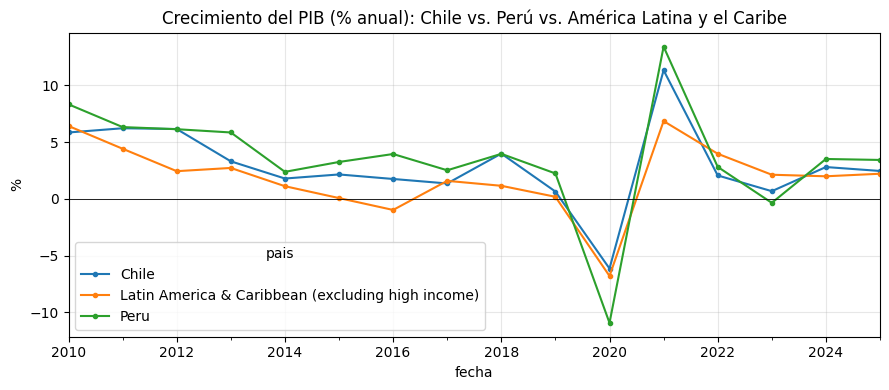

In [101]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
df_pib_pivot.plot(ax=ax, marker="o", ms=3)
ax.axhline(0, color="black", lw=0.6)
ax.set_title("Crecimiento del PIB (% anual): Chile vs. Perú vs. América Latina y el Caribe")
ax.set_ylabel("%")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Hacia el preprocesamiento
Con los datos ya en SQL, el siguiente paso natural no es graficar más series — es prepararlas para análisis: revisar tipos, detectar valores atípicos y datos faltantes, y separar tendencia de ruido. Ese trabajo se hace en profundidad en el cuaderno `04-Limpieza_Imputacion_Tendencia`, sobre el Parquet que arma el cuaderno `03-Extraccion_BancoMundial_Parquet`. Lo que este cuaderno deja listo son los tres formatos de guardado y el criterio para elegir entre ellos — la base para que esa limpieza tenga de dónde partir.

---
## 6. Visualización: matplotlib y plotly
Un número suelto dice poco; una serie de tiempo se entiende mirándola. Vemos dos librerías con roles distintos: matplotlib para figuras estáticas (las que van en un informe o paper) y plotly para gráficos interactivos (los que se exploran dentro del notebook).

### Preparar una serie para graficar
Antes de graficar, aislamos la serie de interés (el Imacec) del resto del `DataFrame`.

In [102]:
imacec = df_raw[df_raw["id_serie"] == "F032.IMC.IND.Z.Z.EP18.Z.Z.0.M"].copy()
imacec["fecha"] = pd.to_datetime(imacec["fecha"])
imacec.tail(3)

,id_serie,fecha,valor
8891,F032.IMC.IND.Z.Z.EP18.Z.Z.0.M,2026-04-01,114.236768
8935,F032.IMC.IND.Z.Z.EP18.Z.Z.0.M,2026-05-01,112.659492
8979,F032.IMC.IND.Z.Z.EP18.Z.Z.0.M,2026-06-01,111.030720


### matplotlib: figura estática
El patrón `fig, ax = plt.subplots()` separa la figura completa (`fig`) de los ejes donde se dibuja (`ax`) — necesario en cuanto se quiere controlar título, etiquetas o combinar varios paneles.

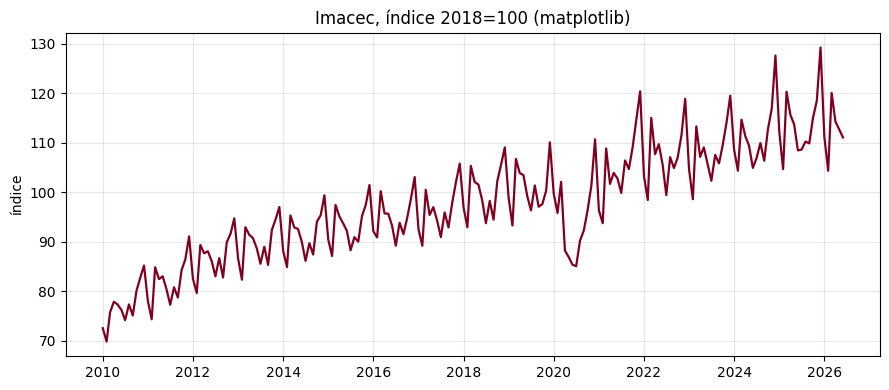

In [103]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(imacec["fecha"], imacec["valor"], color="#800020", lw=1.6)
ax.set_title("Imacec, índice 2018=100 (matplotlib)")
ax.set_ylabel("índice")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### plotly: gráfico interactivo
Misma serie, pero con zoom, tooltips al pasar el mouse y la posibilidad de exportar directo a HTML.

In [104]:
import plotly.express as px

fig = px.line(
    imacec, x="fecha", y="valor",
    title="Imacec, índice 2018=100 (plotly, interactivo)",
    labels={"fecha": "", "valor": "índice"},
)
fig.update_layout(hovermode="x unified", height=400)
fig.show()

**Buenas prácticas para gráficos de coyuntura:** título y unidades explícitas; eje X siempre cronológico con `DatetimeIndex`; niveles y variación en dos paneles separados.

---
## 7. De texto a fechas nativas y el accesor `.dt`
Una fecha que llega como texto (`"2026-03-01"`) se ordena alfabéticamente, no cronológicamente, y no permite calcular "un mes después". Convertirla a un tipo de fecha nativo es lo que habilita todo el trabajo de series de tiempo que viene después.

### El tipo original
Antes de convertir, confirmamos cómo llegó la columna `fecha` desde SQL.

In [105]:
df_raw["fecha"].dtype

dtype('O')

### Convertir a `datetime64`
`pd.to_datetime()` parsea el texto a un tipo de fecha real. `errors='coerce'` convierte en `NaT` (fecha nula) cualquier valor que no se pueda interpretar, en vez de detener la ejecución.

In [106]:
df_raw["fecha"] = pd.to_datetime(df_raw["fecha"], errors="coerce")
df_raw["fecha"].dtype

dtype('<M8[ns]')

### El accesor `.dt`
Una vez que la columna es `datetime64`, el accesor `.dt` extrae componentes — año, mes, día de la semana — con una sintaxis uniforme, igual que `.str` para texto.

In [107]:
df_ejemplo = df_raw.head(500).copy()
df_ejemplo["anio"] = df_ejemplo["fecha"].dt.year
df_ejemplo["mes"] = df_ejemplo["fecha"].dt.month
df_ejemplo["trimestre"] = df_ejemplo["fecha"].dt.quarter
df_ejemplo["nombre_dia"] = df_ejemplo["fecha"].dt.day_name()
df_ejemplo[["id_serie", "fecha", "anio", "mes", "trimestre", "nombre_dia"]].head()

,id_serie,fecha,anio,mes,trimestre,nombre_dia
0,F074.IPC.VAR.Z.Z.C.M,2010-01-01,2010,1,1,Friday
1,F032.IMC.IND.Z.Z.EP18.Z.Z.0.M,2010-01-01,2010,1,1,Friday
2,CPIAUCSL,2010-01-01,2010,1,1,Friday
3,FEDFUNDS,2010-01-01,2010,1,1,Friday
4,WB.FP.CPI.TOTL.ZG.CL,2010-01-01,2010,1,1,Friday


---
## 8. `DatetimeIndex` y selección temporal (slicing)
Con las fechas como índice del `DataFrame` (en vez de una columna más), pandas permite filtrar por período con la misma sintaxis con la que se escribe una fecha — sin construir una condición booleana.

### Indexar por fecha
`set_index('fecha')` mueve la columna de fechas al índice y lo ordena cronológicamente.

In [108]:
df_tco = df_raw[df_raw["id_serie"] == "F073.TCO.PRE.Z.D"].copy()
df_tco = df_tco.set_index("fecha").sort_index()
print("Tipo de indice:", type(df_tco.index))
df_tco.head(3)

Tipo de indice: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


,id_serie,valor
fecha,,
2010-01-04,F073.TCO.PRE.Z.D,507.10
2010-01-05,F073.TCO.PRE.Z.D,505.70
2010-01-06,F073.TCO.PRE.Z.D,504.22


### Slicing por texto parcial (sin filtros booleanos)
Con un `DatetimeIndex`, `.loc["2025"]` o `.loc["2025-01":"2025-06"]` funcionan como un rango — pandas interpreta el texto como período, no como comparación de strings.

In [109]:
df_tco.loc["2025"].head(3)          # todo el ano 2025

,id_serie,valor
fecha,,
2025-01-02,F073.TCO.PRE.Z.D,996.46
2025-01-03,F073.TCO.PRE.Z.D,999.84
2025-01-06,F073.TCO.PRE.Z.D,1011.82


In [110]:
df_tco.loc["2026-03"].head(3)       # todo marzo 2026

,id_serie,valor
fecha,,
2026-03-02,F073.TCO.PRE.Z.D,871.41
2026-03-03,F073.TCO.PRE.Z.D,884.21
2026-03-04,F073.TCO.PRE.Z.D,906.32


In [111]:
df_tco.loc["2025-01":"2025-06"].head(3)   # rango exacto

,id_serie,valor
fecha,,
2025-01-02,F073.TCO.PRE.Z.D,996.46
2025-01-03,F073.TCO.PRE.Z.D,999.84
2025-01-06,F073.TCO.PRE.Z.D,1011.82


---
## 9. Frecuencias temporales y `asfreq`
Una serie diaria del tipo de cambio no tiene una observación por cada día calendario — faltan fines de semana y feriados. `asfreq` fuerza una frecuencia regular y deja a la vista dónde hay huecos.

### Inspeccionar e inferir la frecuencia
`df.index.freq` muestra la frecuencia declarada; `pd.infer_freq()` la deduce a partir del espaciado real de las fechas cuando no está declarada.

In [112]:
print("Frecuencia declarada en el indice:", df_tco.index.freq)
print("Frecuencia inferida               :", pd.infer_freq(df_tco.index))

Frecuencia declarada en el indice: None
Frecuencia inferida               : None


### Forzar una frecuencia regular
`asfreq('B')` revela huecos (feriados, datos faltantes) como `NaN`.

In [113]:
df_tco_b = df_tco.asfreq("B")
huecos = df_tco_b["valor"].isna().sum()
print(f"Observaciones con frecuencia 'B' forzada: {len(df_tco_b)}")
print(f"Huecos revelados (feriados/faltantes)   : {huecos}")

Observaciones con frecuencia 'B' forzada: 4325
Huecos revelados (feriados/faltantes)   : 196


---
## 10. Remuestreo (`resample`): diaria → mensual → trimestral
`resample` cambia la frecuencia de una serie de tiempo agregando (downsampling, de diaria a mensual) o rellenando (upsampling, de mensual a diaria). Es el método que conecta datos de distinta granularidad — necesario en cuanto se combinan series diarias con series mensuales o trimestrales.

### Downsampling: diaria → mensual
Agregamos el tipo de cambio diario a promedios y desviaciones mensuales.

In [114]:
tco_mensual = df_tco["valor"].resample("MS").agg(
    dolar_promedio="mean", dolar_cierre="last", dolar_min="min", dolar_max="max",
)
tco_mensual.tail(6)

,dolar_promedio,dolar_cierre,dolar_min,dolar_max
fecha,,,,
2026-02-01,862.020000,861.19,854.25,868.52
2026-03-01,909.893182,931.57,871.41,931.57
2026-04-01,897.886190,901.76,876.32,927.46
2026-05-01,897.637895,892.89,887.71,910.01
2026-06-01,903.384286,922.34,883.46,922.34
2026-07-01,930.970000,924.78,921.70,946.24


### Downsampling: mensual → trimestral
El mismo método aplicado sobre una serie ya mensual, para bajar un nivel más de frecuencia.

In [115]:
tco_trimestral = tco_mensual["dolar_promedio"].resample("QS").mean().to_frame(name="dolar_promedio_trim")
tco_trimestral.tail(6)

,dolar_promedio_trim
fecha,
2025-04-01,947.002214
2025-07-01,959.407000
2025-10-01,935.277894
2026-01-01,885.292965
2026-04-01,899.636124
2026-07-01,930.970000


### Upsampling: mensual → diaria, evitando look-ahead bias
`ffill()` propaga el último dato conocido; nunca se interpola "hacia atrás" información que no existía en esa fecha.

In [116]:
imacec_di = imacec.set_index("fecha")["valor"].sort_index()
imacec_diario = imacec_di.resample("D").ffill()

print("Observaciones mensuales originales  :", len(imacec_di))
print("Observaciones diarias tras upsampling:", len(imacec_diario))
imacec_diario.tail(5)

Observaciones mensuales originales  : 198
Observaciones diarias tras upsampling: 5996


fecha
2026-05-28    112.659492
2026-05-29    112.659492
2026-05-30    112.659492
2026-05-31    112.659492
2026-06-01    111.030720
Freq: D, Name: valor, dtype: float64

---
## 11. Ejercicios prácticos
Tres ejercicios para practicar remuestreo con series distintas del catálogo — tipo de cambio, TPM y PIB del Banco Mundial.

### Desafío 1
Calcula el promedio **semanal** (`'W'`) del tipo de cambio y encuentra la semana con mayor volatilidad (desviación estándar más alta).

In [117]:
tco_semanal = df_tco["valor"].resample("W").agg(["mean", "std"])
semana_max_vol = tco_semanal["std"].idxmax()
print(f"Semana de mayor volatilidad: {semana_max_vol.date()} (std = {tco_semanal.loc[semana_max_vol, 'std']:.2f})")
tco_semanal.tail()

Semana de mayor volatilidad: 2022-07-17 (std = 28.13)


,mean,std
fecha,,
2026-07-05,923.400,2.647779
2026-07-12,928.010,5.076500
2026-07-19,925.765,2.058049
2026-07-26,936.478,5.638690
2026-08-02,936.916,8.060523


### Desafío 2
Remuestrea la TPM (diaria) a fin de mes tomando el **último valor observado**.

In [118]:
df_tpm = df_raw[df_raw["id_serie"] == "F022.TPM.TIN.D001.NO.Z.D"].set_index("fecha").sort_index()
tpm_mensual = df_tpm["valor"].resample("ME").last()
print(f"Observaciones diarias: {len(df_tpm)} | Observaciones mensuales: {len(tpm_mensual)}")
tpm_mensual.tail(6)

Observaciones diarias: 4130 | Observaciones mensuales: 199


fecha
2026-02-28    4.5
2026-03-31    4.5
2026-04-30    4.5
2026-05-31    4.5
2026-06-30    4.5
2026-07-31    4.5
Freq: ME, Name: valor, dtype: float64

### Desafío 3
Con los datos del Banco Mundial ya cargados en `df_pib_pivot` (sección 5, Comparación internacional), calcula el promedio de crecimiento del PIB 2015-2025 para Chile y para América Latina y el Caribe (`LAC`). ¿Creció Chile más o menos que el promedio regional?

In [119]:
col_lac = [c for c in df_pib_pivot.columns if "Latin America" in c][0]
promedio_2015_2025 = df_pib_pivot.loc["2015":"2025", ["Chile", col_lac]].mean()
print(promedio_2015_2025.round(2))

diferencia = promedio_2015_2025["Chile"] - promedio_2015_2025[col_lac]
print(f"\nChile creció, en promedio, {diferencia:+.2f} puntos porcentuales respecto a LAC (2015-2025).")

pais
Chile                                                2.10
Latin America & Caribbean (excluding high income)    1.13
dtype: float64

Chile creció, en promedio, +0.97 puntos porcentuales respecto a LAC (2015-2025).
